<a href="https://colab.research.google.com/github/Mauricio-Fragoso-Mendoza/Simulacion-I/blob/main/M%C3%A9todo_de_Montecarlo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random as r

Queremos estimar el valor de la integral $$I=\int_{0}^{\frac{\pi}{2}} \sin x dx$$

Para ello usaremos el estimador: $$\hat{I}=\frac{\pi}{2}\frac{n}{N}$$

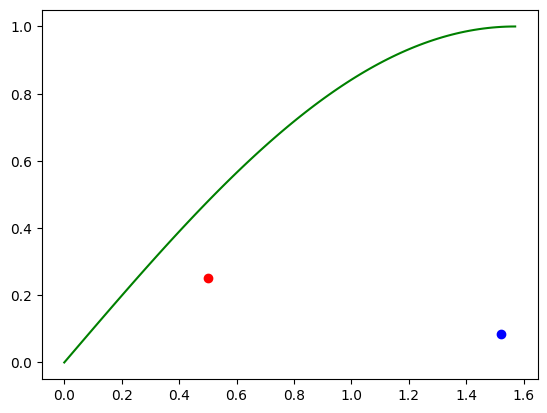

In [3]:
x = np.linspace(0, np.pi/2, 100)
plt.plot(x, np.sin(x), color= 'green')
plt.scatter(0.5, 0.25, color= 'red')
plt.scatter(r.uniform(0, np.pi/2),r.random(), color= 'blue')

In [18]:
def test_function(x):
  return(np.sin(x))

In [29]:
def integrate(x1,x2,func=test_function,n=100):
    X=np.linspace(x1,x2,100)
    y1=0
    y2=max((func(X)))
    print(x1,x2,y1,y2)
    area=(x2-x1)*(y2-y1)
    check=[]
    xs=[]
    ys=[]
    for i in range(n):
        x=np.random.uniform(x1,x2,1)
        xs.append(x)
        y=np.random.uniform(y1,y2,1)
        ys.append(y)
        if abs(y)>abs(func(x)) or y<0:
            check.append(0)
        else:
            check.append(1)
    return(np.mean(check)*area,xs,ys,check)

0 1 0 0.8414709848078965
0.4375649121001062
0 1 0 0.8414709848078965


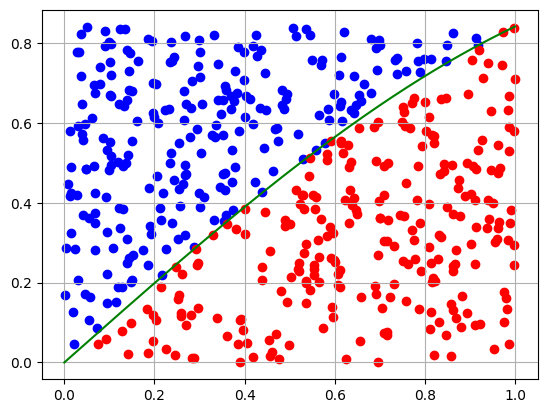

In [30]:
import pandas as pd

print(integrate(0,1,test_function)[0])
_,x,y,c=integrate(0,1,n=500)
df=pd.DataFrame()
df['x']=x
df['y']=y
df['c']=c

X=np.linspace(0,1,1000)
plt.grid(True)
plt.plot(X,test_function(X),color='green')
plt.scatter(df[df['c']==0]['x'],df[df['c']==0]['y'],color='blue')
plt.scatter(df[df['c']==1]['x'],df[df['c']==1]['y'],color='red')
plt.show()